#GitHub link
[My GitHub Repository](https://github.com/finnesaa/Data-Analytics-Project-1.git)



#Kaggle dataset
[link text](https://kaggle.com/datasets/zahranusratt/e-commerce-orders-and-sales-performance-dataset)

The dataset I chose for this assignment is an E-commerce performance dataset.The dataset contains e-commerce order iinformation from 2022-2024, including the order date, product name, category, region, quantity, sales, profit. It represents transactional data that reflects how online retail platforms record daily orders, track product performance, and monitor financial outcomes. I chose this dataset since it is common for data analysts to work with businesses in order to support data-driven decision making.

The main inquiry of this dataset I want to explore is how do product categories and regions affect e-commerce sales and profit ? This can be broken down into three-sub questions.

Which product categories generate the most sales and profit ?

How do sales and profit compare across the 4 regions ?

Is there a relationship between the quantity of products sold and the amount of sales generated ?





In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
#Import and look at the data
df = pd.read_csv('ecommerce_sales.csv')
print(df)


      Order Date Product Name     Category Region  Quantity  Sales   Profit
0     2024-12-31      Printer       Office  North         4   3640   348.93
1     2022-11-27        Mouse  Accessories   East         7   1197   106.53
2     2022-05-11       Tablet  Electronics  South         5   5865   502.73
3     2024-03-16        Mouse  Accessories  South         2    786   202.87
4     2022-09-10        Mouse  Accessories   West         1    509   103.28
...          ...          ...          ...    ...       ...    ...      ...
3495  2023-02-15      Monitor  Accessories  North         4   4064   771.16
3496  2022-09-18      Monitor  Accessories   East         1   1117   119.89
3497  2022-04-12       Laptop  Electronics  South         4    260    66.02
3498  2022-01-18      Printer       Office  South         3    222    50.28
3499  2024-11-01   Smartwatch  Electronics   East         9  10530  1777.32

[3500 rows x 7 columns]


Overview of dataset

In [3]:
#Check size of dataset
print("shape",df.shape)

shape (3500, 7)


In [4]:
#Check column headers
print("Column Headers\n", df.columns.tolist())

Column Headers
 ['Order Date', 'Product Name', 'Category', 'Region', 'Quantity', 'Sales', 'Profit']


In [5]:
#Check data types
print(df.dtypes)

Order Date       object
Product Name     object
Category         object
Region           object
Quantity          int64
Sales             int64
Profit          float64
dtype: object


In [6]:
#Check the first 10 rows of data
print(df.head(10))

   Order Date Product Name     Category Region  Quantity  Sales   Profit
0  2024-12-31      Printer       Office  North         4   3640   348.93
1  2022-11-27        Mouse  Accessories   East         7   1197   106.53
2  2022-05-11       Tablet  Electronics  South         5   5865   502.73
3  2024-03-16        Mouse  Accessories  South         2    786   202.87
4  2022-09-10        Mouse  Accessories   West         1    509   103.28
5  2023-12-01       Camera  Electronics   West         1    524   106.35
6  2023-10-09   Headphones  Accessories  North         7   6167  1027.98
7  2022-01-14       Camera  Electronics  South         7   3059   873.50
8  2022-04-02   Smartwatch  Electronics   East         9   5526   595.28
9  2024-10-22      Printer       Office  South         8    672   186.37


In [7]:
#Check last 10 rows of data
print(df.tail(10))

      Order Date Product Name     Category Region  Quantity  Sales   Profit
3490  2023-05-14       Laptop  Electronics   West         9   9702  2771.49
3491  2023-09-04     Keyboard  Accessories   East         8   5888   354.27
3492  2023-09-20       Tablet  Electronics   East         4   1768   345.33
3493  2022-06-01   Headphones  Accessories  North         2   1022    76.04
3494  2023-12-03       Tablet  Electronics  North         3   2883   671.91
3495  2023-02-15      Monitor  Accessories  North         4   4064   771.16
3496  2022-09-18      Monitor  Accessories   East         1   1117   119.89
3497  2022-04-12       Laptop  Electronics  South         4    260    66.02
3498  2022-01-18      Printer       Office  South         3    222    50.28
3499  2024-11-01   Smartwatch  Electronics   East         9  10530  1777.32


Data cleaning

In [8]:
#Check for NULL values
print(df.isnull().sum())

Order Date      0
Product Name    0
Category        0
Region          0
Quantity        0
Sales           0
Profit          0
dtype: int64


In [9]:
#Check duplicates
print(df.duplicated().sum())

0


In [10]:
#Change data type for Order Date, currently Object when it should be DateTime
print(df['Order Date'].dtype)

object


In [11]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
print(df['Order Date'].dtype)

datetime64[ns]


In [12]:
#Check valid inputs
df['Category'].head(20)

,Category
0,Office
1,Accessories
2,Electronics
3,Accessories
4,Accessories
5,Electronics
6,Accessories
7,Electronics
8,Electronics
9,Office


In [ ]:
df['Region'].head(20)

,Region
0,North
1,East
2,South
3,South
4,West
5,West
6,North
7,South
8,East
9,South


In [ ]:
df['Product Name'].head(20)

,Product Name
0,Printer
1,Mouse
2,Tablet
3,Mouse
4,Mouse
5,Camera
6,Headphones
7,Camera
8,Smartwatch
9,Printer


In [18]:
#Check outliers
#First determine cut off value for outlier
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(lower)
print(upper)

print(IQR)

-4181.75
9768.25
3487.5


     Order Date Product Name     Category Region  Quantity  Sales  Profit
0    2024-12-31      Printer       Office  North         4   3640  348.93
1    2022-11-27        Mouse  Accessories   East         7   1197  106.53
2    2022-05-11       Tablet  Electronics  South         5   5865  502.73
3    2024-03-16        Mouse  Accessories  South         2    786  202.87
4    2022-09-10        Mouse  Accessories   West         1    509  103.28
...         ...          ...          ...    ...       ...    ...     ...
3494 2023-12-03       Tablet  Electronics  North         3   2883  671.91
3495 2023-02-15      Monitor  Accessories  North         4   4064  771.16
3496 2022-09-18      Monitor  Accessories   East         1   1117  119.89
3497 2022-04-12       Laptop  Electronics  South         4    260   66.02
3498 2022-01-18      Printer       Office  South         3    222   50.28

[3465 rows x 7 columns]


<Axes: >

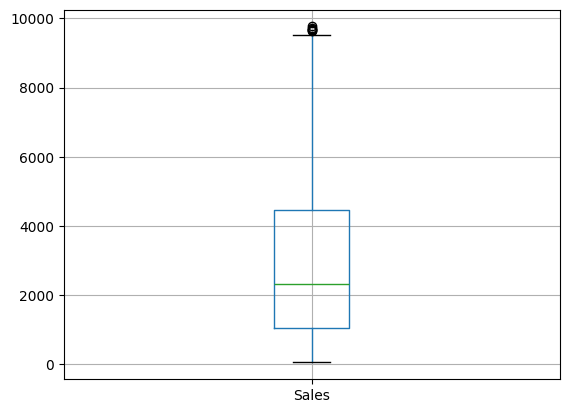

In [22]:
#Check outliers
df_nooutlier = df[df['Sales'] <= upper]
print(df_nooutlier)
df_nooutlier.boxplot(column=['Sales'])

     Order Date Product Name     Category Region  Quantity  Sales   Profit
0    2024-12-31      Printer       Office  North         4   3640   348.93
1    2022-11-27        Mouse  Accessories   East         7   1197   106.53
2    2022-05-11       Tablet  Electronics  South         5   5865   502.73
3    2024-03-16        Mouse  Accessories  South         2    786   202.87
4    2022-09-10        Mouse  Accessories   West         1    509   103.28
...         ...          ...          ...    ...       ...    ...      ...
3495 2023-02-15      Monitor  Accessories  North         4   4064   771.16
3496 2022-09-18      Monitor  Accessories   East         1   1117   119.89
3497 2022-04-12       Laptop  Electronics  South         4    260    66.02
3498 2022-01-18      Printer       Office  South         3    222    50.28
3499 2024-11-01   Smartwatch  Electronics   East         9  10530  1777.32

[3500 rows x 7 columns]


<Axes: >

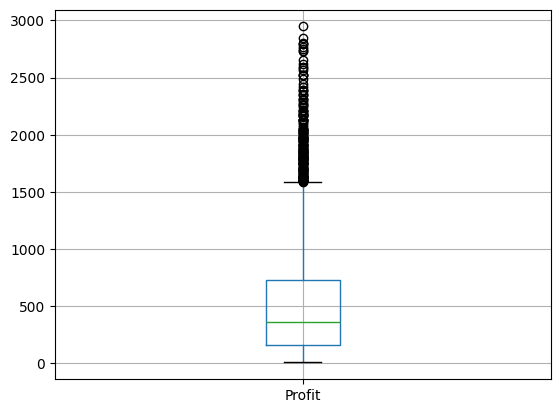

In [23]:
df_nooutlier = df[df['Profit'] <= upper]
print(df_nooutlier)
df_nooutlier.boxplot(column=['Profit'])

     Order Date Product Name     Category Region  Quantity  Sales   Profit
0    2024-12-31      Printer       Office  North         4   3640   348.93
1    2022-11-27        Mouse  Accessories   East         7   1197   106.53
2    2022-05-11       Tablet  Electronics  South         5   5865   502.73
3    2024-03-16        Mouse  Accessories  South         2    786   202.87
4    2022-09-10        Mouse  Accessories   West         1    509   103.28
...         ...          ...          ...    ...       ...    ...      ...
3495 2023-02-15      Monitor  Accessories  North         4   4064   771.16
3496 2022-09-18      Monitor  Accessories   East         1   1117   119.89
3497 2022-04-12       Laptop  Electronics  South         4    260    66.02
3498 2022-01-18      Printer       Office  South         3    222    50.28
3499 2024-11-01   Smartwatch  Electronics   East         9  10530  1777.32

[3500 rows x 7 columns]


<Axes: >

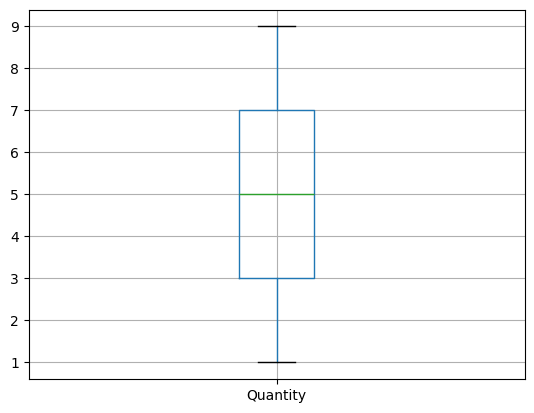

In [24]:
df_nooutlier = df[df['Quantity'] <= upper]
print(df_nooutlier)
df_nooutlier.boxplot(column=['Quantity'])

               Sales     Profit
Category                       
Accessories  4247591  736084.74
Electronics  5326074  923185.59
Office       1094216  185394.88


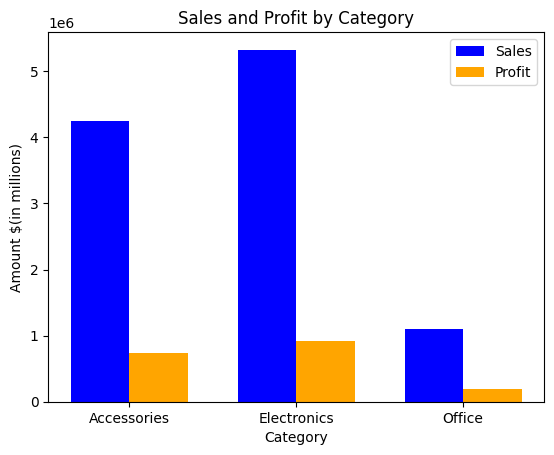

In [52]:
#Graph for sales and profit by category
sales_profit_by_category= df.groupby('Category')[['Sales', 'Profit']].sum()
print(sales_profit_by_category)
x_axis=np.arange(3)
width= 0.35
plt.bar(x_axis - width/2, sales_profit_by_category['Sales'], width, label='Sales', color='blue')
plt.bar(x_axis + width/2, sales_profit_by_category['Profit'], width, label='Profit', color='orange')
plt.xlabel('Category')
plt.ylabel('Amount $(in millions)')
plt.title('Sales and Profit by Category')
plt.xticks(x_axis, sales_profit_by_category.index)
plt.legend()
plt.show()

 The bar graph shows the which product generates the most sales and profit for each category in the dataset. The electronics category has the highest amount of sales and profit. Electronics has about $5,000,000 in sales and approximately $900,000 in profit. The office category has the least amount of sales and profit, with approximately $1,000,000 in sales and approximately $200,000 in profit. This shows that  the elctronics category contributes the most to profit/sales, while the office category contributes the least.  

          Sales     Profit
Region                    
East    2675110  464888.46
North   2488773  426314.75
South   2659548  458103.27
West    2844450  495358.73


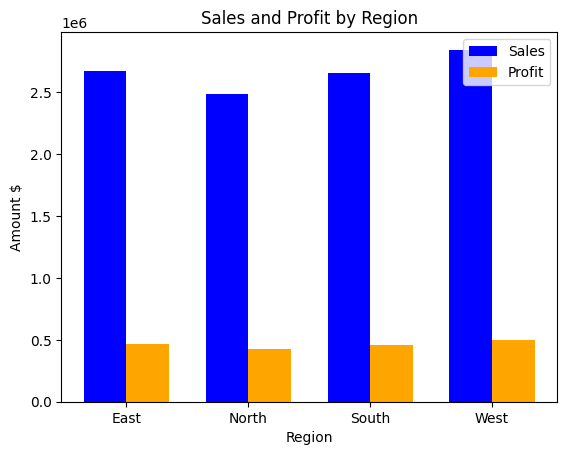

In [51]:
#Graph for sales and profit by region
sales_profit_by_region= df.groupby('Region')[['Sales', 'Profit']].sum()
print(sales_profit_by_region)

x_axis=np.arange(4)
width=0.35
plt.bar(x_axis - width/2, sales_profit_by_region['Sales'], width, label='Sales', color='blue')
plt.bar(x_axis + width/2, sales_profit_by_region['Profit'], width, label='Profit', color='orange')
plt.xlabel('Region')
plt.ylabel('Amount $')
plt.title('Sales and Profit by Region')
plt.xticks(x_axis, sales_profit_by_region.index)
plt.legend()
plt.show()

This graph shows the sales and profit based on a region. The dataset has North, South, East, and West for the regions. The West has the highest amount of sales and profit, while the North has the lowest. The East and South has a s imilar amount of sales and profit. This graph shows that there aren't many differences between the regions. The sales and profits are split evenly between the four regions. This shows that  differences in profit/sales is effected more by category of product rather than region.                                                                            

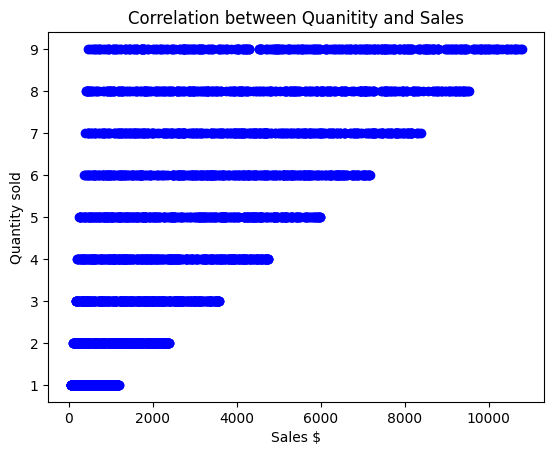

The correlation between Quantity and Sales is 0.6624675829425261


In [49]:
#Graph to show correlation
x= df['Sales']
y= df['Quantity']
plt.scatter(x, y, marker='o', color  ='blue')
plt.xlabel('Sales $')
plt.ylabel('Quantity sold')
plt.title('Correlation between Quanitity and Sales')
plt.show()

correlation= df['Quantity'].corr(df['Sales'])
print(f"The correlation between Quantity and Sales is {correlation}")

This graph shows the correlation between quantity sold and sales. There is a strong positive correlation between both variables which suggests that as quantity of products sold increases, sales also increase.

 The purpose of this project is to analyze the sales records for e-commerce to investigate  differences in sales and profits across product categories and regions and to examine the relationship between the quantity sold and total amount of sales.

 The first graph shows that the Electronics category has the highest total sales and profit among all the other categories in the dataset. While the Office category has the lowest.

 The second graph shows differences in sales and profit among the four regions. The West has the highest total of sales and profit, while the North has the least. Although there isn't a remarkable difference across the four regions.

 The third graph shows a positive correlation between quantity and sales, with a correlation of approximately 0.662.

 The dataset is limited with the amount of data it has. There are several other factors that effect a business's sales and profit that aren't a part of the dataset. For example, customer demographics or behaviors. This is something that can show why we see the patterns that we see in the data. Further analysis can explain trends or seasonal patterns and indivudal product profitability. Exploring this can help the business determine what products to market during which times to increase sales or which product to increase production of if it is a high seller.